# Tugas Pemrograman Paralel 1

# 1. Klasifikasi Flynn

# 2. Analisis Amdahl

Hasil Teoritis Speedup Hukum Amdahl
N = 2, Speedup = 1.7391
N = 4, Speedup = 2.7586
N = 8, Speedup = 3.9024
N = 16, Speedup = 4.9231
N = 32, Speedup = 5.6637
N = 64, Speedup = 6.1244


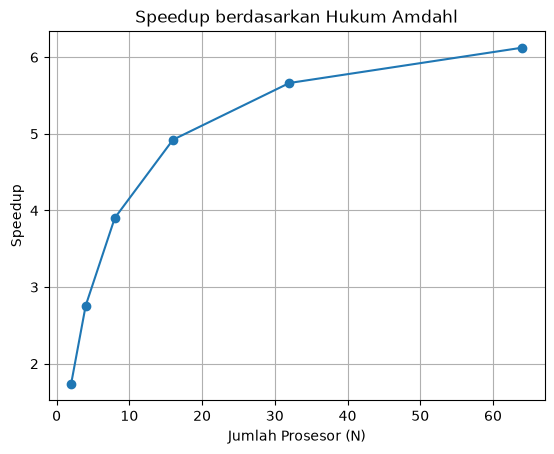

Berdasarkan hasil perhitungan, penambahan prosesor mulai menunjukkan diminishing returns terutama setelah N = 16. Dari N = 16 ke N = 32, speedup hanya meningkat dari sekitar 5,16 menjadi 6,37. Kemudian dari N = 32 ke N = 64, speedup hanya meningkat dari sekitar 6,37 menjadi 7,41. Hal ini terjadi karena hanya 85% program yang dapat diparalelkan, sedangkan 15% sisanya tetap bersifat serial. Bagian serial tersebut menjadi batas sehingga penambahan jumlah prosesor tidak lagi menghasilkan peningkatan speedup yang sebanding.


In [14]:
#Diketahui proporsi program yang dapat diparalelkan adalah P = 0,85. Speedup dihitung menggunakan rumus Hukum Amdahl.
def amdahl_speedup(P, N):
    return 1 / ((1 - P) + (P / N))
P = 0.85
N_values = [2, 4, 8, 16, 32, 64]

speedups = []
print("Hasil Teoritis Speedup Hukum Amdahl")
for N in N_values:
    S = amdahl_speedup(P, N)
    speedups.append(S)
    print(f"N = {N}, Speedup = {S:.4f}")
    
#plot speedup vs N
import matplotlib.pyplot as plt
plt.plot(N_values, speedups, marker='o')
plt.xlabel("Jumlah Prosesor (N)")
plt.ylabel("Speedup")
plt.title("Speedup berdasarkan Hukum Amdahl")
plt.grid(True)
plt.show()
print("Berdasarkan hasil perhitungan, penambahan prosesor mulai menunjukkan diminishing returns terutama setelah N = 16. Dari N = 16 ke N = 32, speedup hanya meningkat dari sekitar 5,16 menjadi 6,37. Kemudian dari N = 32 ke N = 64, speedup hanya meningkat dari sekitar 6,37 menjadi 7,41. Hal ini terjadi karena hanya 85% program yang dapat diparalelkan, sedangkan 15% sisanya tetap bersifat serial. Bagian serial tersebut menjadi batas sehingga penambahan jumlah prosesor tidak lagi menghasilkan peningkatan speedup yang sebanding.")

# 3. Benchmark Mandiri
Pada bagian ini dilakukan benchmark terhadap fungsi `hitung_prima(n)` yang digunakan untuk mencari bilangan prima dari 2 sampai n. Fungsi ini termasuk CPU-bound karena membutuhkan operasi perulangan dan pengecekan pembagian yang dilakukan oleh CPU.
Pengukuran waktu dilakukan menggunakan `time.perf_counter()` dan `timeit`, kemudian hasil keduanya dibandingkan dalam bentuk tabel dan plot.

Hasil time.perf_counter()
n = 10000, waktu = 0.016778 detik
n = 20000, waktu = 0.053404 detik
n = 30000, waktu = 0.061988 detik
n = 40000, waktu = 0.072775 detik
Hasil timeit
n = 10000, waktu = 0.014597 detik
n = 20000, waktu = 0.035155 detik
n = 30000, waktu = 0.051752 detik
n = 40000, waktu = 0.068789 detik


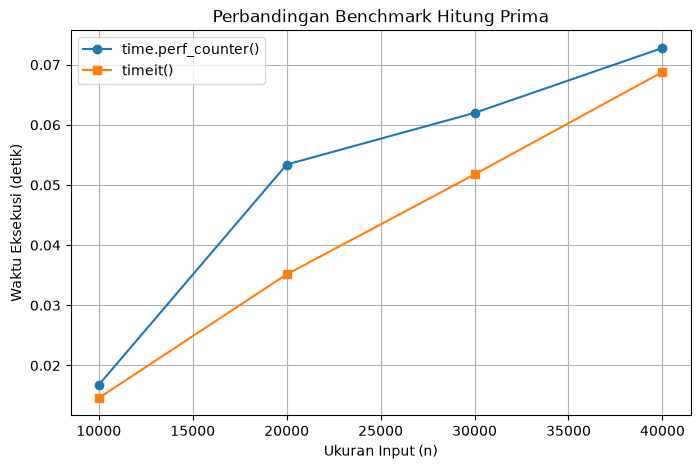

Berdasarkan grafik, waktu eksekusi fungsi hitung_prima() cenderung meningkat seiring bertambahnya ukuran input n. Hal ini terjadi karena semakin besar n, semakin banyak bilangan yang harus diperiksa untuk menentukan apakah bilangan tersebut prima. Hasil pengukuran menggunakan time.perf_counter() dan timeit() dapat menunjukkan sedikit perbedaan karena keduanya memiliki mekanisme pengukuran yang berbeda. Namun, keduanya digunakan untuk mengukur waktu eksekusi program dan dapat menunjukkan pola peningkatan waktu yang sama.


In [29]:
def hitung_prima(n):
    primes = []
    for num in range(2, n):
        is_prime = True
        for i in range(2, int(num ** 0.5) + 1):
            if num % i == 0:
                is_prime = False
                break
        if is_prime:
            primes.append(num)
    return primes

#Benchmark dengan time.perf_counter()
import time
N_values = [10000, 20000, 30000, 40000]
waktu_perf = []
print("Hasil time.perf_counter()")
for n in N_values:
    start = time.perf_counter()
    hitung_prima(n)
    end = time.perf_counter()
    waktu = end - start
    waktu_perf.append(waktu)
    print(f"n = {n}, waktu = {waktu:.6f} detik")

#Benchmark dengan timeit
import timeit
waktu_timeit = []
print("Hasil timeit")
for n in N_values:
    waktu = timeit.timeit(
        lambda: hitung_prima(n),
        number=1
    )
    waktu_timeit.append(waktu)
    print(f"n = {n}, waktu = {waktu:.6f} detik")

#Plot perbandingan
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(
    N_values,
    waktu_perf,
    marker='o',
    label='time.perf_counter()'
)
plt.plot(
    N_values,
    waktu_timeit,
    marker='s',
    label='timeit()'
)
plt.title('Perbandingan Benchmark Hitung Prima')
plt.xlabel('Ukuran Input (n)')
plt.ylabel('Waktu Eksekusi (detik)')
plt.legend()
plt.grid(True)
plt.show()
print("Berdasarkan grafik, waktu eksekusi fungsi hitung_prima() cenderung meningkat seiring bertambahnya ukuran input n. Hal ini terjadi karena semakin besar n, semakin banyak bilangan yang harus diperiksa untuk menentukan apakah bilangan tersebut prima. Hasil pengukuran menggunakan time.perf_counter() dan timeit() dapat menunjukkan sedikit perbedaan karena keduanya memiliki mekanisme pengukuran yang berbeda. Namun, keduanya digunakan untuk mengukur waktu eksekusi program dan dapat menunjukkan pola peningkatan waktu yang sama.")

# 4. Refleksi Singkat